<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [974]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [975]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [976]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [977]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [978]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [979]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [980]:
# 함수 만들기
def build_model_input(data):

    # 1. 결측치 처리
    num_cols = data.select_dtypes(include=['number']).columns
    cat_cols = data.select_dtypes(include=['object', 'category']).columns

    for col in num_cols:
        data[col].fillna(data[col].median(), inplace=True)
    for col in cat_cols:
        data[col].fillna(data[col].mode()[0], inplace=True)


    # 2. 값 변경
    data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

    # 3. 변수 제거
    data.drop(columns=['Unnamed: 0', 'ID'], inplace=True)


    # 4. 라벨 인코딩
    cat_cols = data.select_dtypes(include='object').columns

    for col in cat_cols:
        encoder = LabelEncoder()
        data[col] = encoder.fit_transform(data[col])


    # 5. 가변수화
    categories = [0, 1, 2, 3, 4, 5]
    dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
                'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
                'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
    for col in dumm_cols:
        data[col] = pd.Categorical(data[col], categories=categories)

    data = pd.get_dummies(data, columns=dumm_cols)


    # 6. x, y 분리
    target = 'Satisfaction'

    x = data.drop(target, axis=1)
    y = data.loc[:, target]


    # 7. 스케일링

    x = scaler.transform(x)

    # 반환
    return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [981]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 92)
(350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [982]:
print(x_val.shape)
print(y_val.shape)

(350, 92)
(350,)


### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [983]:
# x_val, y_val 나누기
#x_val, y_val = build_model_input(new_test)


## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [984]:
#x_train, y_train으로 나누
x_train, y_train = build_model_input(new_train)

In [985]:
print(y_train.value_counts(dropna=False))

Satisfaction
0    463
1    387
Name: count, dtype: int64


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [952]:
# 메모리 정리
clear_session()

#오버샘플링
ros = RandomOverSampler(sampling_strategy=1.0, random_state=42)
x_train_over, y_train_over = ros.fit_resample(x_train, y_train)

# 입력 Feature 수
nfeatures = x_train_over.shape[1]

# Sequential 모델 선언 0.2을 줘서 뉴련은 20프로 꺼버립니다
model1 = Sequential([
    Input(shape=(nfeatures, )),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

# 모델 요약
model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [953]:
# 학습 설정
model1.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.001, restore_best_weights=True, patience=8, verbose=1)

In [954]:
# 모델 학습
hist = model1.fit(x_train_over, y_train_over, batch_size=16, epochs=60, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history

Epoch 1/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5000 - loss: 0.7125 - val_accuracy: 0.4800 - val_loss: 0.6824
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6242 - loss: 0.6415 - val_accuracy: 0.7314 - val_loss: 0.6111
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7765 - loss: 0.5300 - val_accuracy: 0.8571 - val_loss: 0.4677
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8607 - loss: 0.3976 - val_accuracy: 0.8743 - val_loss: 0.3436
Epoch 5/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8844 - loss: 0.3084 - val_accuracy: 0.8971 - val_loss: 0.2791
Epoch 6/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9125 - loss: 0.2557 - val_accuracy: 0.9057 - val_loss: 0.2486
Epoch 7/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9147 - loss: 0.2330 - val_accuracy: 0.9171 - val_loss: 0.2335
Epoch 8/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9114 - loss: 0.2185 - val_accuracy: 0.9057 - val_loss

- 학습 곡선을 확인합니다.

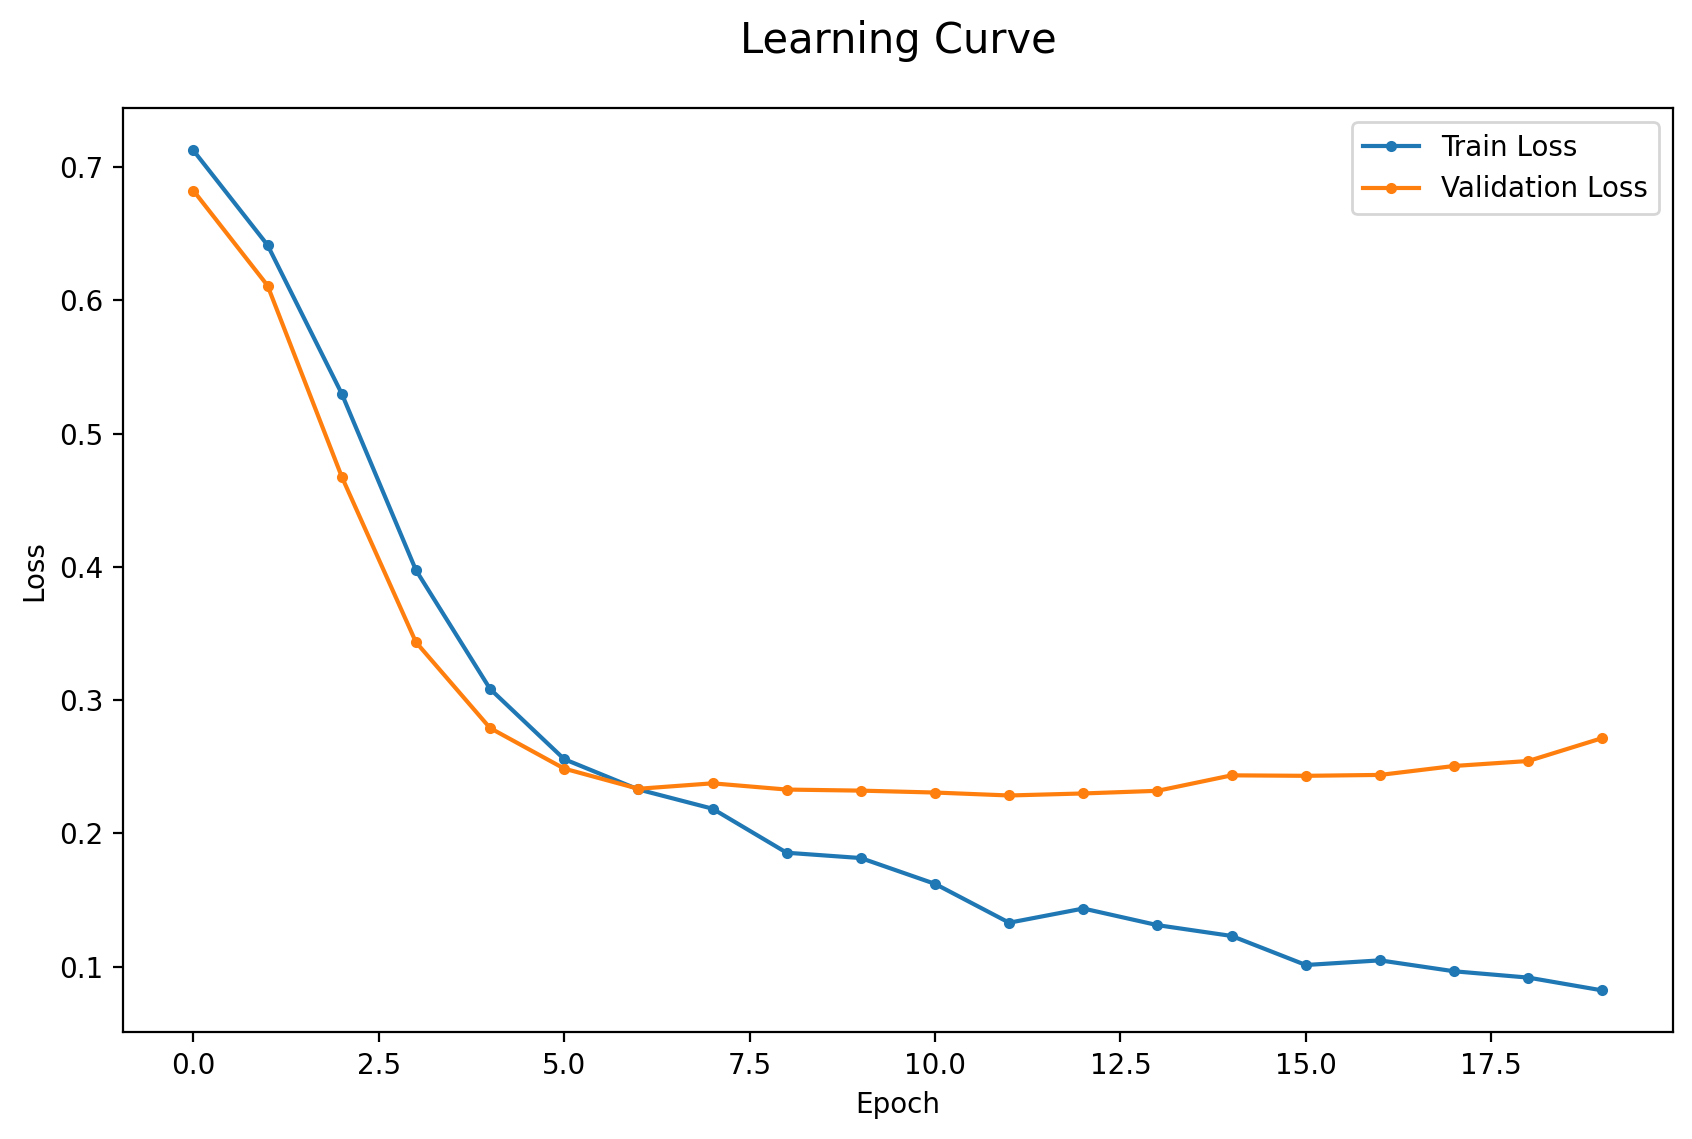

In [955]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [956]:
# 예측
y_pred1 = model1.predict(x_val)
y_pred1 = np.where(y_pred1 >= 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [957]:
# 성능 평가
print(confusion_matrix(y_val, y_pred1))
print('-'*60)
print(classification_report(y_val, y_pred1))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred1))

[[176  15]
 [ 13 146]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       191
           1       0.91      0.92      0.91       159

    accuracy                           0.92       350
   macro avg       0.92      0.92      0.92       350
weighted avg       0.92      0.92      0.92       350

------------------------------------------------------------
Accuracy: 0.92


### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [958]:
# 기본 모델링에서 썼던 모델링은 오버샘플링을 추가 하였으나, 이제 데이터 불균형이 해소되어 오버 샘플링을 지우고 코드 개선
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언 0.2을 줘서 뉴련은 20프로 꺼버립니다
model2 = Sequential([
    base_model,

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

# 모델 요약
model2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 1)              │         8,577 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,330 (44.26 KB)

 Trainable params: 11,330 (44.26 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [959]:
# 학습 설정
model2.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.001, restore_best_weights=True, patience=8, verbose=1)

In [960]:
# 모델 학습
hist = model2.fit(x_train, y_train, batch_size=16, epochs=60, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history

Epoch 1/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.8847 - loss: 0.6352 - val_accuracy: 0.9257 - val_loss: 0.5880
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9400 - loss: 0.5337 - val_accuracy: 0.9314 - val_loss: 0.4669
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9459 - loss: 0.4069 - val_accuracy: 0.9457 - val_loss: 0.3439
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9588 - loss: 0.2838 - val_accuracy: 0.9429 - val_loss: 0.2599
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9671 - loss: 0.1905 - val_accuracy: 0.9429 - val_loss: 0.2181
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9624 - loss: 0.1733 - val_accuracy: 0.9400 - val_loss: 0.2032
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9729 - loss: 0.1207 - val_accuracy: 0.9400 - val_loss: 0.2178
Epoch 8/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9753 - loss: 0.1144 - val_accuracy: 0.9371 - val_loss

- 학습 곡선을 확인합니다.

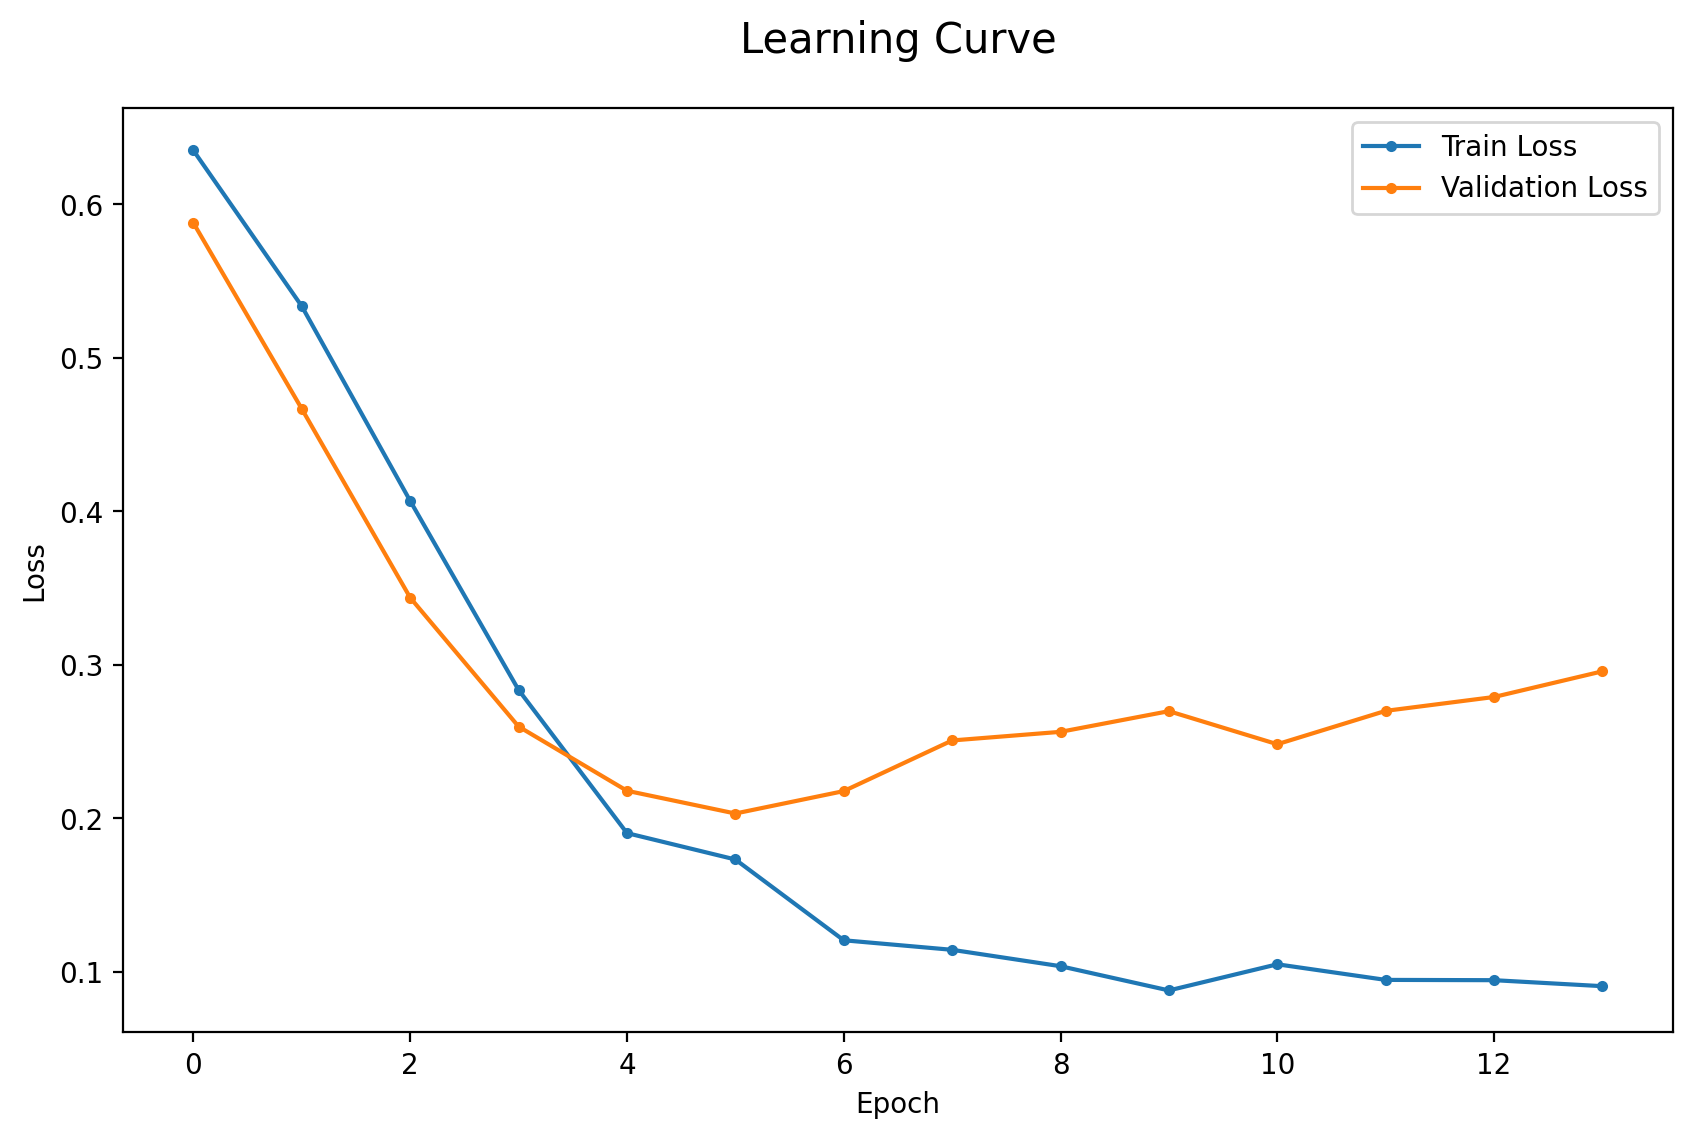

In [961]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [962]:
# 예측
y_pred2 = model2.predict(x_val)
y_pred2 = np.where(y_pred2 >= 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [963]:
# 성능 평가
print(confusion_matrix(y_val, y_pred2))
print('-'*60)
print(classification_report(y_val, y_pred2))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred2))

[[182   9]
 [ 12 147]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       191
           1       0.94      0.92      0.93       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

------------------------------------------------------------
Accuracy: 0.94


### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [986]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_3, built=True>

In [987]:
# 모델 선언
model = base_model

In [988]:
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [989]:
model3 = Sequential([

         base_model,

         Dense(32, activation='relu'),
         Dropout(0.4),

         Dense(16, activation='relu'),
         Dropout(0.2),

         Dense(8, activation='relu'),

         Dense(1, activation='sigmoid')
])
# 모델 요약
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 16)             │         8,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,777 (38.19 KB)

 Trainable params: 3,825 (14.94 KB)

 Non-trainable params: 5,952 (23.25 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [990]:
# 학습 설정
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.0005, restore_best_weights=True, patience=8, verbose=1)

In [991]:
# 모델 학습
hist = model3.fit(x_train, y_train, batch_size=16, epochs=100, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.4600 - loss: 0.9343 - val_accuracy: 0.4543 - val_loss: 0.7119
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4765 - loss: 0.8075 - val_accuracy: 0.4629 - val_loss: 0.6087
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4929 - loss: 0.7142 - val_accuracy: 0.8029 - val_loss: 0.5581
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5341 - loss: 0.6520 - val_accuracy: 0.8314 - val_loss: 0.5434
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5353 - loss: 0.6289 - val_accuracy: 0.8429 - val_loss: 0.5358
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5929 - loss: 0.5571 - val_accuracy: 0.8543 - val_loss: 0.5260
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6082 - loss: 0.5643 - val_accuracy: 0.8629 - val_loss: 0.5089
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6671 - loss: 0.5344 - val_accuracy: 0.8629 - 

- 학습 곡선을 확인합니다.

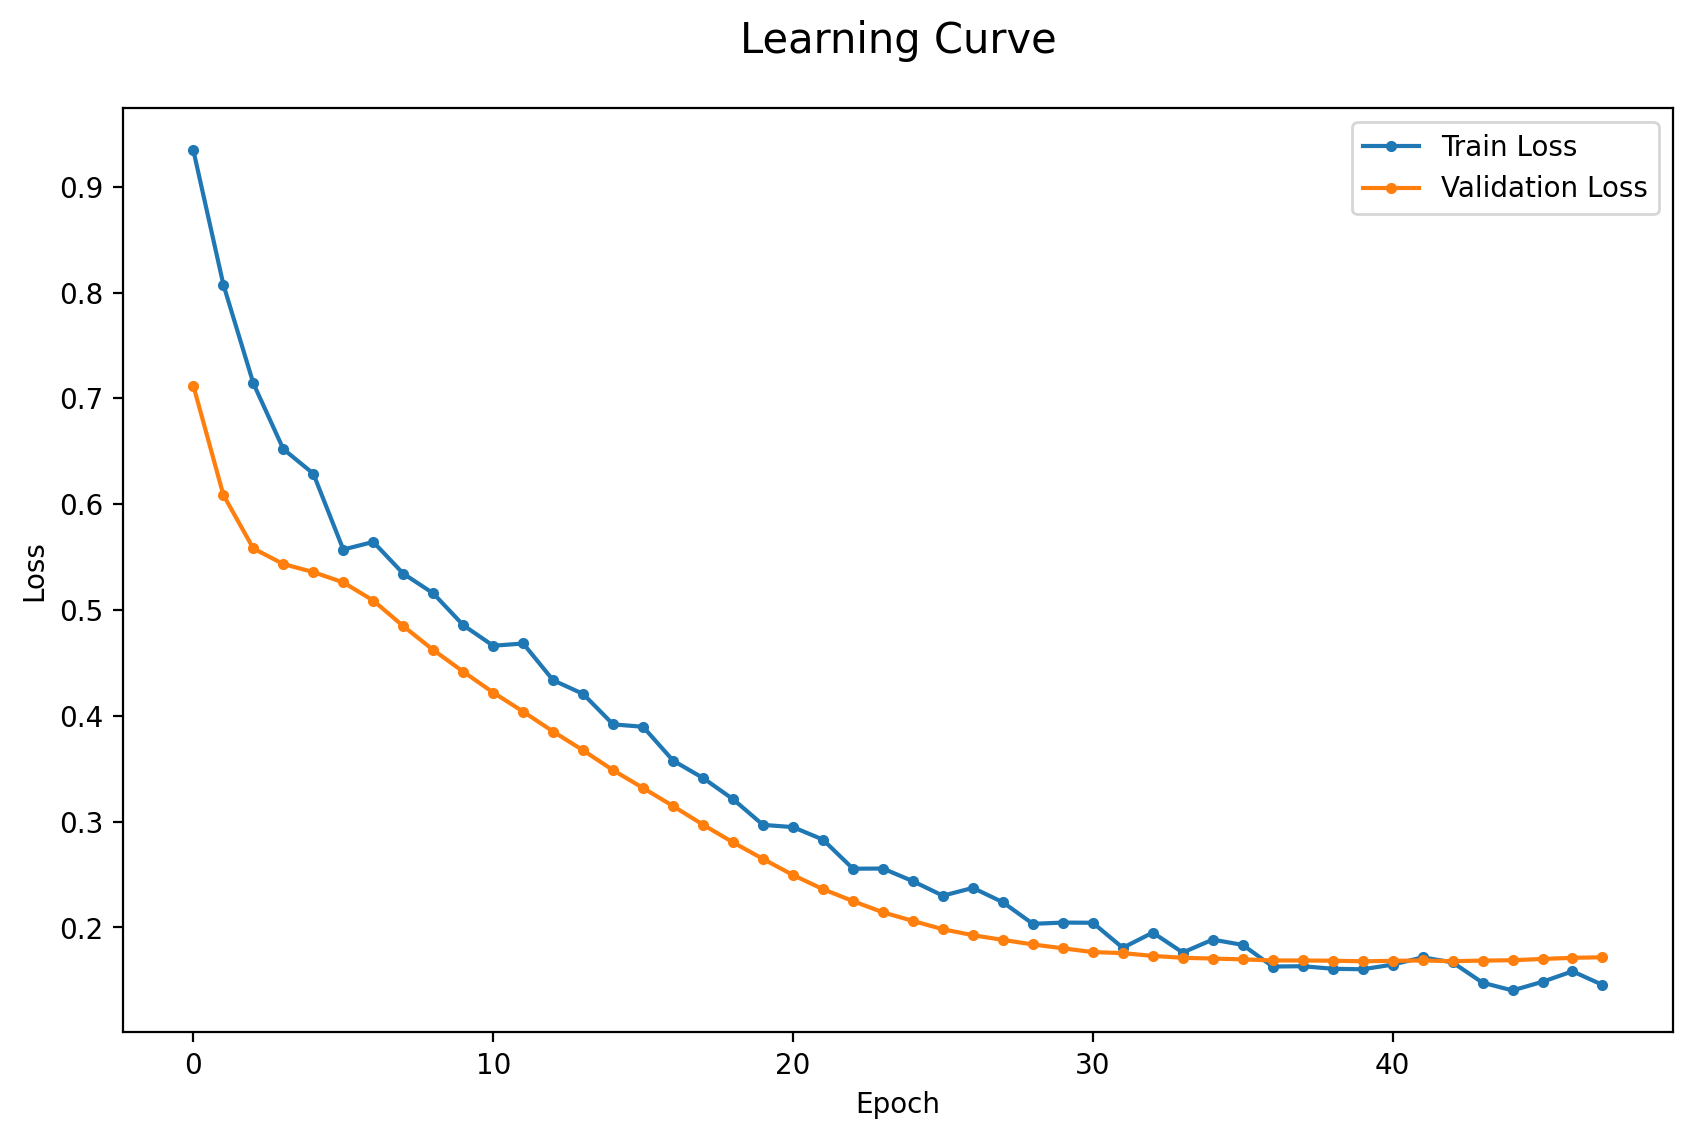

In [992]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [993]:
 #예측
y_pred3 = model3.predict(x_val)
y_pred3 = np.where(y_pred3 >= 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [994]:
# 성능 평가
print(confusion_matrix(y_val, y_pred3))
print('-'*60)
print(classification_report(y_val, y_pred3))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred3))

[[181  10]
 [ 10 149]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       191
           1       0.94      0.94      0.94       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

------------------------------------------------------------
Accuracy: 0.9428571428571428


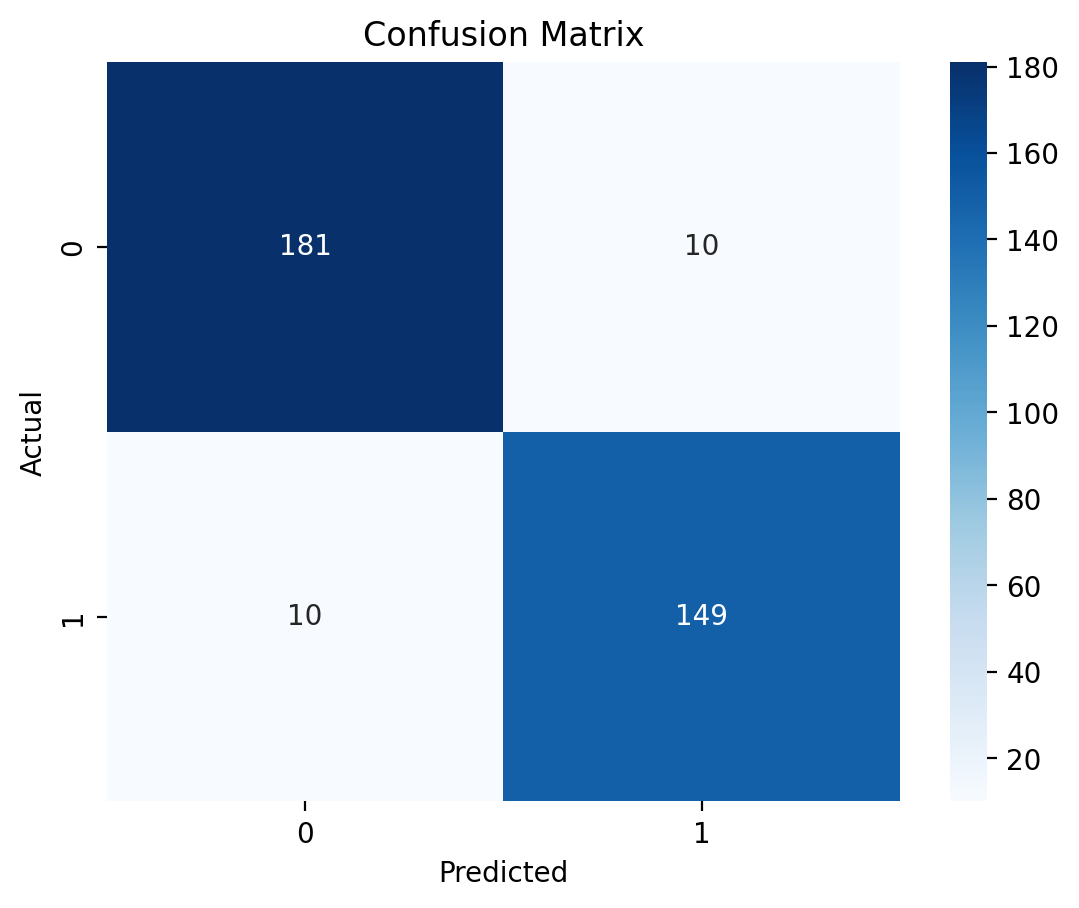

In [995]:
cm = confusion_matrix(y_val, y_pred3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()